# Day 20 — Text Preprocessing & Feature Extraction

**Objective:** Clean raw text and convert it into numerical features that ML models can use.

Topics: cleaning, tokenization, stopwords, stemming, lemmatization, one-hot encoding, Bag of Words, and TF-IDF.

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 1. Sample Text Dataset

We use small customer-review examples so every preprocessing step is easy to inspect.

In [3]:
texts = [
    "I absolutely LOVE this product!!!",
    "The product is good, but the delivery was slow.",
    "Amazing quality and excellent service.",
    "I do NOT like this product.",
    "The product arrived late and damaged.",
    "Very happy with my purchase!"
]

df = pd.DataFrame({"text": texts})
df


,text
0,I absolutely LOVE this product!!!
1,"The product is good, but the delivery was slow."
2,Amazing quality and excellent service.
3,I do NOT like this product.
4,The product arrived late and damaged.
5,Very happy with my purchase!


## 2. Lowercasing

Convert text to lowercase so `Product`, `product`, and `PRODUCT` are treated consistently in this traditional NLP pipeline.

In [4]:
df["lowercase"] = df["text"].str.lower()
df[["text", "lowercase"]]


,text,lowercase
0,I absolutely LOVE this product!!!,i absolutely love this product!!!
1,"The product is good, but the delivery was slow.","the product is good, but the delivery was slow."
2,Amazing quality and excellent service.,amazing quality and excellent service.
3,I do NOT like this product.,i do not like this product.
4,The product arrived late and damaged.,the product arrived late and damaged.
5,Very happy with my purchase!,very happy with my purchase!


## 3. Remove Punctuation and Extra Spaces

In [5]:
def clean_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["lowercase"].apply(clean_text)
df[["text", "clean_text"]]


,text,clean_text
0,I absolutely LOVE this product!!!,i absolutely love this product
1,"The product is good, but the delivery was slow.",the product is good but the delivery was slow
2,Amazing quality and excellent service.,amazing quality and excellent service
3,I do NOT like this product.,i do not like this product
4,The product arrived late and damaged.,the product arrived late and damaged
5,Very happy with my purchase!,very happy with my purchase


## 4. Tokenization

Tokenization breaks text into smaller units called tokens.

In [6]:
df["tokens"] = df["clean_text"].apply(word_tokenize)
df[["clean_text", "tokens"]]


,clean_text,tokens
0,i absolutely love this product,"[i, absolutely, love, this, product]"
1,the product is good but the delivery was slow,"[the, product, is, good, but, the, delivery, w..."
2,amazing quality and excellent service,"[amazing, quality, and, excellent, service]"
3,i do not like this product,"[i, do, not, like, this, product]"
4,the product arrived late and damaged,"[the, product, arrived, late, and, damaged]"
5,very happy with my purchase,"[very, happy, with, my, purchase]"


## 5. Stopword Handling

Stopwords are common words that may add little information for some tasks. We preserve `not`, `no`, and `never` because negation can be important for sentiment.

In [7]:
stop_words = set(stopwords.words("english"))
for word in ["not", "no", "never"]:
    stop_words.discard(word)

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["tokens_no_stopwords"] = df["tokens"].apply(remove_stopwords)
df[["tokens", "tokens_no_stopwords"]]


,tokens,tokens_no_stopwords
0,"[i, absolutely, love, this, product]","[absolutely, love, product]"
1,"[the, product, is, good, but, the, delivery, w...","[product, good, delivery, slow]"
2,"[amazing, quality, and, excellent, service]","[amazing, quality, excellent, service]"
3,"[i, do, not, like, this, product]","[not, like, product]"
4,"[the, product, arrived, late, and, damaged]","[product, arrived, late, damaged]"
5,"[very, happy, with, my, purchase]","[happy, purchase]"


## 6. Stemming

Stemming reduces words to a root-like form. The result may not always be a valid dictionary word.

In [8]:
stemmer = PorterStemmer()
words = ["playing", "played", "plays", "studies", "studying"]

pd.DataFrame({
    "Original": words,
    "Stemmed": [stemmer.stem(w) for w in words]
})


,Original,Stemmed
0,playing,play
1,played,play
2,plays,play
3,studies,studi
4,studying,studi


## 7. Lemmatization

Lemmatization attempts to produce a meaningful dictionary base form.

In [9]:
lemmatizer = WordNetLemmatizer()
words = ["playing", "played", "plays", "studies", "studying", "better"]

pd.DataFrame({
    "Original": words,
    "Lemmatized": [lemmatizer.lemmatize(w, pos="v") for w in words]
})


,Original,Lemmatized
0,playing,play
1,played,play
2,plays,play
3,studies,study
4,studying,study
5,better,better


## 8. Final Preprocessed Text

Convert the remaining tokens back into strings for vectorization.

In [10]:
df["processed_text"] = df["tokens_no_stopwords"].apply(lambda x: " ".join(x))
df[["text", "processed_text"]]


,text,processed_text
0,I absolutely LOVE this product!!!,absolutely love product
1,"The product is good, but the delivery was slow.",product good delivery slow
2,Amazing quality and excellent service.,amazing quality excellent service
3,I do NOT like this product.,not like product
4,The product arrived late and damaged.,product arrived late damaged
5,Very happy with my purchase!,happy purchase


## 9. One-Hot Encoding

Each vocabulary word gets a binary vector.

Example: `cat → [1,0,0]`, `dog → [0,1,0]`, `fish → [0,0,1]`.

One-hot encoding is simple but does not capture semantic similarity.

In [11]:
vocabulary = ["cat", "dog", "fish"]
one_hot = pd.DataFrame(
    [[1 if i == j else 0 for i in range(len(vocabulary))]
     for j in range(len(vocabulary))],
    index=vocabulary,
    columns=vocabulary
)
one_hot


,cat,dog,fish
cat,1,0,0
dog,0,1,0
fish,0,0,1


## 10. Bag of Words (BoW)

BoW represents each document using word counts. It does not capture word order or deeper context.

In [12]:
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(df["processed_text"])

bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("Matrix shape:", X_bow.shape)
bow_df


Vocabulary: ['absolutely' 'amazing' 'arrived' 'damaged' 'delivery' 'excellent' 'good'
 'happy' 'late' 'like' 'love' 'not' 'product' 'purchase' 'quality'
 'service' 'slow']
Matrix shape: (6, 17)


,absolutely,amazing,arrived,damaged,delivery,excellent,good,happy,late,like,love,not,product,purchase,quality,service,slow
0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1
2,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0
3,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0
4,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0
5,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0


## 11. TF-IDF

**TF-IDF = Term Frequency × Inverse Document Frequency**

It gives more importance to words that are distinctive within the document collection.

In [13]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("Vocabulary:", tfidf_vectorizer.get_feature_names_out())
print("Matrix shape:", X_tfidf.shape)
tfidf_df.round(3)


Vocabulary: ['absolutely' 'amazing' 'arrived' 'damaged' 'delivery' 'excellent' 'good'
 'happy' 'late' 'like' 'love' 'not' 'product' 'purchase' 'quality'
 'service' 'slow']
Matrix shape: (6, 17)


,absolutely,amazing,arrived,damaged,delivery,excellent,good,happy,late,like,love,not,product,purchase,quality,service,slow
0,0.652,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.652,0.000,0.387,0.000,0.0,0.0,0.000
1,0.000,0.0,0.000,0.000,0.546,0.0,0.546,0.000,0.000,0.000,0.000,0.000,0.324,0.000,0.0,0.0,0.546
2,0.000,0.5,0.000,0.000,0.000,0.5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.5,0.5,0.000
3,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.652,0.000,0.652,0.387,0.000,0.0,0.0,0.000
4,0.000,0.0,0.546,0.546,0.000,0.0,0.000,0.000,0.546,0.000,0.000,0.000,0.324,0.000,0.0,0.0,0.000
5,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.707,0.000,0.000,0.000,0.000,0.000,0.707,0.0,0.0,0.000


## 12. Visualize Average TF-IDF Importance

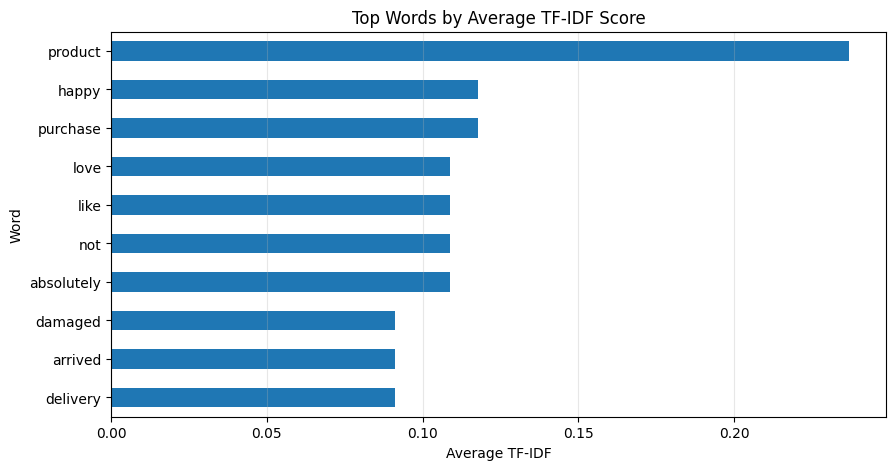

In [14]:
mean_tfidf = tfidf_df.mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
mean_tfidf.sort_values().plot(kind="barh")
plt.title("Top Words by Average TF-IDF Score")
plt.xlabel("Average TF-IDF")
plt.ylabel("Word")
plt.grid(axis="x", alpha=0.3)
plt.show()


## 13. Mini Exercise

1. Add five new reviews.
2. Compare original and cleaned text.
3. Try stemming and lemmatization.
4. Change `CountVectorizer()` to `ngram_range=(1,2)`.
5. Compare BoW and TF-IDF matrices.

In [15]:
new_text = "The delivery was extremely fast and the product quality was excellent!"

new_clean = clean_text(new_text.lower())
new_tokens = word_tokenize(new_clean)
new_tokens_no_stopwords = remove_stopwords(new_tokens)

print("Original:", new_text)
print("Tokens:", new_tokens)
print("After stopword handling:", new_tokens_no_stopwords)


Original: The delivery was extremely fast and the product quality was excellent!
Tokens: ['the', 'delivery', 'was', 'extremely', 'fast', 'and', 'the', 'product', 'quality', 'was', 'excellent']
After stopword handling: ['delivery', 'extremely', 'fast', 'product', 'quality', 'excellent']


# Key Takeaways

- **Tokenization** → breaks text into tokens.
- **Stopword handling** → removes or keeps common words depending on the task.
- **Stemming** → root-like word reduction.
- **Lemmatization** → meaningful base form.
- **One-Hot** → binary token representation.
- **BoW** → word-count representation.
- **TF-IDF** → word-importance representation.

### Core Pipeline

`Raw Text → Preprocessing → Numerical Features → ML Model`